### **Machine Learning: aplicado a dados imobilísticos do Paquistão**
Equipe: Gabriel Souza Dunkel, Guilherme Henriques Almeida, Luca Torres Villela

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import numpy as np

pd.options.display.max_rows = None
df = pd.read_csv('pakistan_house_prices.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99499 entries, 0 to 99498
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     99499 non-null  int64  
 1   property_type  99499 non-null  object 
 2   price          99499 non-null  int64  
 3   location       99499 non-null  object 
 4   city           99499 non-null  object 
 5   baths          99499 non-null  int64  
 6   purpose        99499 non-null  object 
 7   bedrooms       99499 non-null  int64  
 8   Area_in_Marla  99499 non-null  float64
dtypes: float64(1), int64(4), object(4)
memory usage: 6.8+ MB


### **Tipo de cada coluna:**
- unnamed: Categórica e Nominal (um tipo de id)
- property_type: Categórica e Nominal
- price: Numérica e Razão
- location: Categórica e Nominal
- city: Categórica e Nominal
- baths e bedrooms: Numérica e Razão
- purpose: Categórica e Nominal (For sale, for rent)
- Area_in_marla: Numérica e Razão

### **Tratamentos iniciais necessários**
- A função *info()* nos mostrou que não há dados nulos ou faltantes. Por isso não removeremos linhas e não faremos inputação
- Removeremos a coluna "unnamed" pois é um tipo de ID e não vai ajudar na análise ou predicão de dados
- Percebemos então que existem alguns dados onde o valor da area e da quantidade de quartos é 0
- Decidimos remover esses dados, não achamos que valia a pena fazer a análise para "prever" os valores
- 10 linhas onde a "Area_in_Marla" = 0, e 294 linhas onde "bedrooms" = 0
- Finalmente faremos a conversão de Marla para metros quadrados na coluna "Area_in_Marla" para uma melhor compreensão
- Valores pareciam meio absurdos, com isso assumimos que eles estavam em Rupees (moeda local do Paquistão). Com isso, fizemos a conversão para melhor compreensão dos dados



In [31]:
clean_df = df.copy()
clean_df.drop(columns=['Unnamed: 0'], inplace=True)
clean_df = clean_df[clean_df['Area_in_Marla'] != 0] #remover linhas com area 0  (10 linhas)
clean_df = clean_df[clean_df['bedrooms'] != 0] #remover linhas com quartos 0    (294 linhas)
clean_df['area'] = df['Area_in_Marla'] * 25.292852 #converter de Marla pra metro quadrado
clean_df['area'] = clean_df['area'].round(0).astype(int) #converter valor pra inteiro pq normalmente é assim em anuncios de imóveis 
clean_df['price'] = df['price'] / 52 # converter de Rupee para Reais
clean_df['price'] = clean_df['price'].round(2) # arredondamento para 2 casas decimais
clean_df.drop(columns=['Area_in_Marla'], inplace=True)

print("Número de linhas removidas na limpeza dos dados:")
print(len(df) - len(clean_df))

print("Número de linhas restantes após limpeza dos dados:")
print(len(clean_df))

clean_df.head(10)

# df_farm_house = clean_df[clean_df['property_type'] == 'Farm House'] 
# df_farm_house.sort_values(by='price', ascending=True).head(10)

# print(len(clean_df[clean_df['bedrooms'] == 0]))
# clean_df.sort_values(by='bedrooms', ascending=True).head(10)

Número de linhas removidas na limpeza dos dados:
304
Número de linhas restantes após limpeza dos dados:
99195


,property_type,price,location,city,baths,purpose,bedrooms,area
0,Flat,192307.69,G-10,Islamabad,2,For Sale,2,101
1,Flat,132692.31,E-11,Islamabad,3,For Sale,3,142
2,House,317307.69,G-15,Islamabad,6,For Sale,5,202
3,House,836538.46,Bani Gala,Islamabad,4,For Sale,4,1012
4,House,134615.38,DHA Defence,Islamabad,3,For Sale,3,202
5,Flat,150000.00,E-11,Islamabad,2,For Sale,2,157
6,Penthouse,769230.77,F-11,Islamabad,5,For Sale,5,506
7,Flat,673076.92,Diplomatic Enclave,Islamabad,3,For Sale,3,180
8,Flat,259615.38,DHA Defence,Islamabad,5,For Sale,3,253
9,Flat,69230.77,E-11,Islamabad,1,For Sale,1,78


### **Observação de Outliers**
Fazendo umas queries e observando a média de metros quadrados por tipo de propriedade, observamos alguns valores absurdos:

#### Variação do Tamanho (area) por Tipo e Localização:


In [32]:
%matplotlib inline
sns.set_theme(style="whitegrid")

# A melhor forma de ver "como varia" é com agregações e gráficos.

# 1: Média de área por TIPO de propriedade
print("  Média de área por tipo de propriedade:")
media_area_por_tipo = clean_df.groupby('property_type')['area'].mean().sort_values(ascending=False)
print(media_area_por_tipo)
print("\n")

# 2: Média de área por CIDADE
# (Usar 'city' é geralmente melhor que 'location', que pode ter valores demais)
print("  Média de área por cidade:")
media_area_por_cidade = clean_df.groupby('city')['area'].mean().sort_values(ascending=False)
print(media_area_por_cidade.all)
print("\n")


  Média de área por tipo de propriedade:
property_type
Farm House       2064.840909
Upper Portion     312.621539
Lower Portion     288.786592
Penthouse         269.641732
House             231.005722
Room              227.936170
Flat              151.283809
Name: area, dtype: float64


  Média de área por cidade:
<bound method Series.all of city
Islamabad     282.800866
Lahore        216.162909
Rawalpindi    206.147604
Karachi       196.433284
Faisalabad    175.837314
Name: area, dtype: float64>




In [33]:
#Breve query que mostra as 'n' maiores áreas por tipo de propriedade:
area_maxima = clean_df[clean_df['property_type'] == 'Flat']['area'].nlargest(10)
area_maxima

76517    4350
76151    2732
99403    2732
14548    2226
94199    2125
85886    2023
46456    1922
45293    1821
75945    1821
79275    1821
Name: area, dtype: int64

### Decidimos então fazer um box plot para verificar os outliers

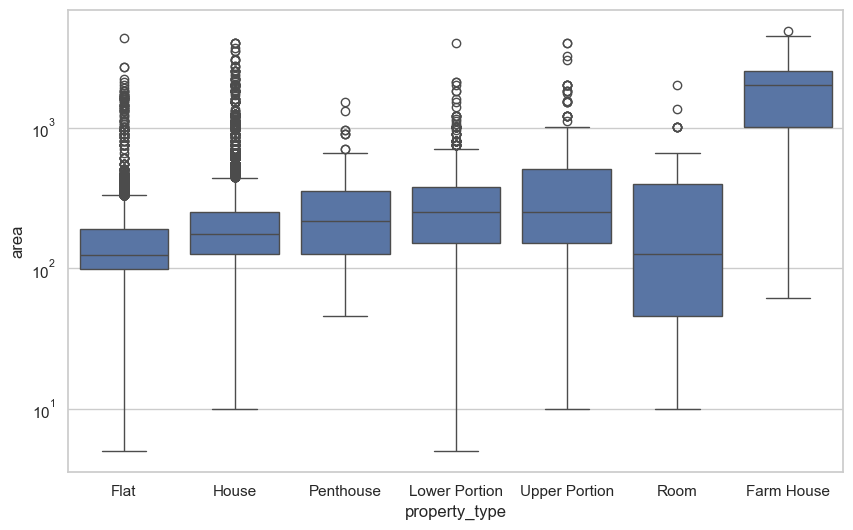

In [34]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='property_type', y='area', data=clean_df)
plt.yscale('log')
plt.show()

### **Tratamento efetivo dos outliers**

In [35]:
#função que remove os outliers
def remove_outliers_by_group(df, column, group, lower_q=0.1, upper_q=0.9):
    return df.groupby(group, group_keys=False).apply(
        lambda x: x[(x[column] > x[column].quantile(lower_q)) &
                    (x[column] < x[column].quantile(upper_q))]
    )

df_outliers = remove_outliers_by_group(clean_df, 'area', 'property_type')

C:\Users\gabriel.dunkel.N305-3033103\AppData\Local\Temp\ipykernel_26188\1201141877.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group, group_keys=False).apply(


In [36]:
#criação da coluna preço por sqm para reduzir enviezamento de resultados
df_outliers['price_per_sqm'] = df_outliers['price'] / df_outliers['area']
df_outliers['price_per_sqm'] = df_outliers['price_per_sqm'].round(2)

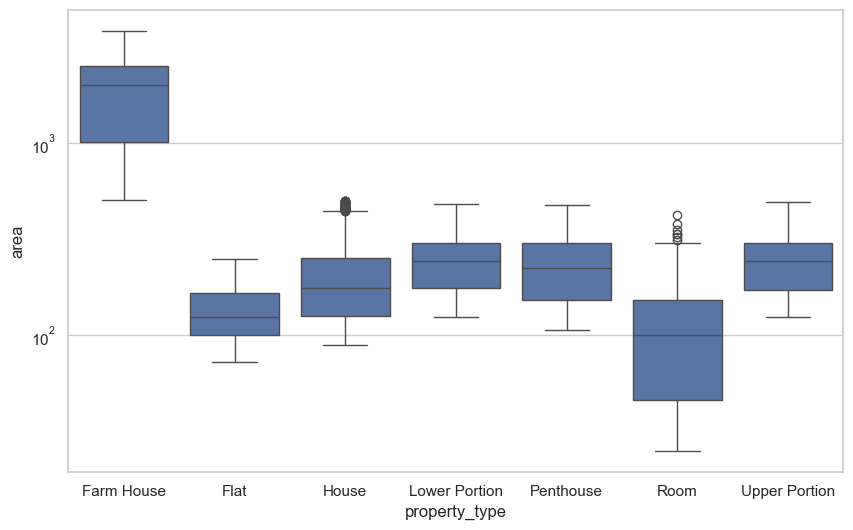

In [37]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='property_type', y='area', data=df_outliers)
plt.yscale('log')
plt.show()

Mesmo com a remoção de outliers, House e Rooms ainda apresentam caudas. Consideramos que House faz sentido por causa de eventuais mansões, mas que em rooms deve haver algo errado, então fomos investigar.

In [38]:
#Breve query que mostra as 'n' maiores áreas por tipo de propriedade:
pd.set_option('display.max_rows', None)
topn = df_outliers[df_outliers['property_type'] == 'Room'].sort_values(by='price_per_sqm', ascending=False).head(12)
topn

,property_type,price,location,city,baths,purpose,bedrooms,area,price_per_sqm
30371,Room,336538.46,D-12,Islamabad,4,For Sale,4,101,3332.06
8395,Room,73076.92,Jaranwala Road,Faisalabad,1,For Sale,1,25,2923.08
15160,Room,269230.77,Gadap Town,Karachi,3,For Sale,3,162,1661.92
68197,Room,192307.69,Johar Town,Lahore,5,For Sale,5,126,1526.25
26201,Room,201923.08,Soan Garden,Islamabad,7,For Sale,5,152,1328.44
95946,Room,423076.92,DHA Defence,Islamabad,5,For Sale,4,326,1297.78
3633,Room,48076.92,Faisal Town - F-18,Islamabad,1,For Sale,1,48,1001.60
11543,Room,25000.00,Shahdara,Lahore,1,For Sale,1,25,1000.00
76974,Room,55769.23,Punjab Coop Housing Society,Lahore,2,For Sale,1,68,820.14
23476,Room,57692.31,Golra Mor,Islamabad,2,For Sale,2,152,379.55


Observando essa query vemos que valores absurdos pra quartos surgem a partir dos $32 por m2. Com isso, vamos removê-los, são apenas 10 linhas que vão mais atrapalhar do que ajudar.

In [39]:
final_df = df_outliers[~((df_outliers['property_type'] == 'Room') & (df_outliers['price_per_sqm'] > 40))]
final_df[final_df['property_type'] == 'Room']['price_per_sqm'].max()

np.float64(32.97)

### Mesmo depois de todos esses tratamentos, ainda há um problema com os property_type 'Room'
- quando calculamos a média das áreas, para todos outros tipos de propriedades as metragens fazem sentido menos para os quartos.

In [40]:
print("  Média de área por tipo de propriedade:")
media_area_por_tipo = final_df.groupby('property_type')['area'].mean().sort_values(ascending=False)
print(media_area_por_tipo)
print("\n")

  Média de área por tipo de propriedade:
property_type
Farm House       1992.579710
Penthouse         239.622449
Lower Portion     234.338887
Upper Portion     234.031656
House             189.409019
Flat              135.006925
Room              122.280576
Name: area, dtype: float64




- Por grande parte dos dados 'Room' se encaixarem no grupo 'Área de valor absurdo' e por sí só rooms serem poucos valores (140 linhas) tinhamos apenas 2 opções plausíveis: Dropar todos os rooms ou sintetizar o valor da área.
- A título de aprendizagem, decidimos sintetizar o valor da área usando os valores maximos e minimos e garantindo que o tamanho dos rooms estejam num intervalo plausível.

🧾 Rooms antes: 139 | depois: 139
📐 Média de área antes: 122.28 | depois: 17.61


C:\Users\gabriel.dunkel.N305-3033103\AppData\Local\Temp\ipykernel_26188\3290874071.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 7.82426123  5.18817965 23.64016327  8.57737145 16.10866945  6.6945959
 12.34311836  5.56473476  5.18817965 14.2258939   5.18817965  5.18817965
  9.70703677  5.56473476  6.6945959   8.20081634  5.56473476  5.
  6.6945959   5.56473476  5.18817965  6.6945959   8.57737145 29.28868572
 21.75738772 16.10866945  8.57737145  8.57737145  5.18817965  7.44770612
  7.44770612  8.01244087  5.56473476 23.64016327  7.44770612  7.44770612
 29.28868572 12.34311836  6.6945959  11.21325721  8.57737145  5.18817965
  7.82426123  8.57737145  6.6945959   8.57737145 14.2258939   6.31784497
 50.          8.57737145  5.18817965  5.37655511 14.2258939   5.18817965
 12.34311836  6.31784497  5.18817965  6.6945959   5.75311022 10.46014699
  6.6945959   9.33048167  6.31784497  6.6945959  12.34311836

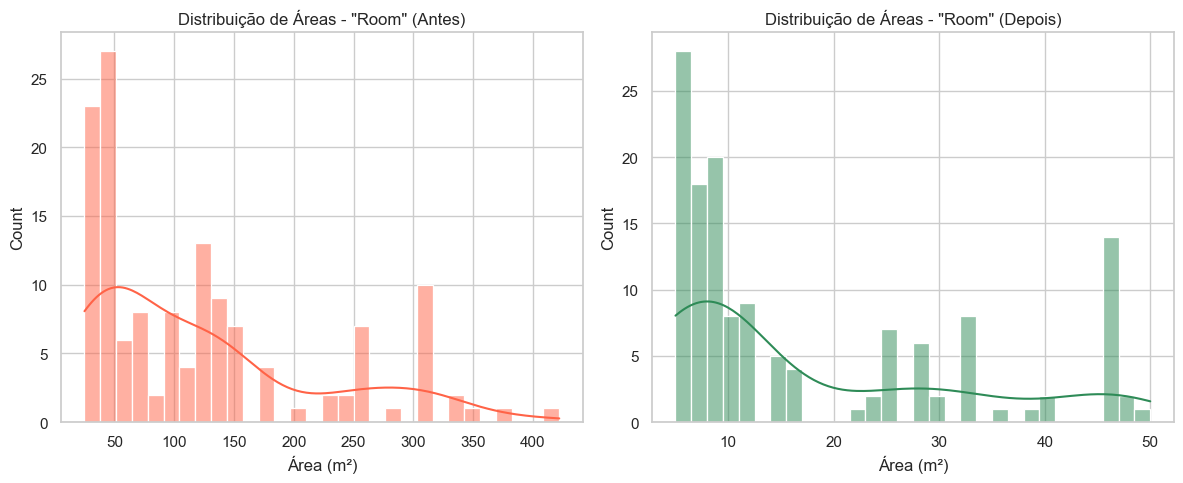

In [41]:
mean_ppsqm_flat = final_df.loc[final_df['property_type'] == 'Flat', 'price_per_sqm'].mean()

before = final_df.loc[final_df['property_type'] == 'Room', 'area'].copy()

mask = (final_df['property_type'] == 'Room') & ((final_df['area'] < 5) | (final_df['area'] > 50))

# Normalizar os preços dos Rooms inválidos (escala 0–1)
min_price = final_df.loc[mask, 'price'].min()
max_price = final_df.loc[mask, 'price'].max()

# Calcular nova área proporcional ao preço
#    - Preços baixos -> área perto de 5 m²
#    - Preços altos -> área perto de 50 m²
final_df.loc[mask, 'area'] = 5 + (
    (final_df.loc[mask, 'price'] - min_price) /
    (max_price - min_price)
) * (50 - 5)

final_df['price_per_sqm'] = final_df['price'] / final_df['area']

before_count = before.shape[0]
after_count = final_df.loc[final_df['property_type'] == 'Room'].shape[0]

before_mean = before.mean()
after_mean = final_df.loc[final_df['property_type'] == 'Room', 'area'].mean()

print(f'🧾 Rooms antes: {before_count} | depois: {after_count}')
print(f'📐 Média de área antes: {before_mean:.2f} | depois: {after_mean:.2f}')

final_df['area'] = final_df['area'].round(0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(before, bins=30, kde=True, ax=axes[0], color='tomato')
axes[0].set_title('Distribuição de Áreas - "Room" (Antes)')
axes[0].set_xlabel('Área (m²)')

sns.histplot(final_df.loc[final_df['property_type'] == 'Room', 'area'],
             bins=30, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Distribuição de Áreas - "Room" (Depois)')
axes[1].set_xlabel('Área (m²)')

plt.tight_layout()
plt.show()

### **Histograma agora muito melhor distribuido**
- Nova média é de 17.6 para quartos

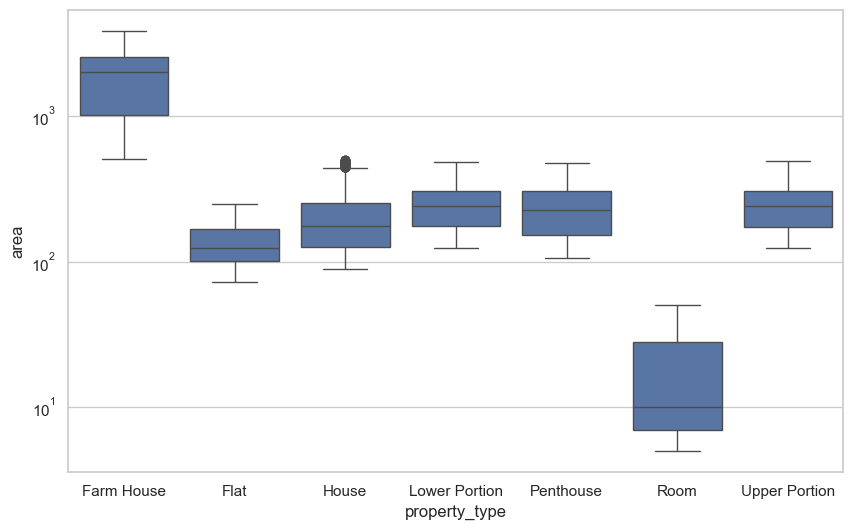

In [42]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='property_type', y='area', data=final_df)
plt.yscale('log')
plt.show()

### Análise Exploratória dos Dados Geral

In [43]:
pd.reset_option('display.max_rows')
clean_df = final_df.copy()
clean_df.info()
clean_df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 73136 entries, 2166 to 99470
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  73136 non-null  object 
 1   price          73136 non-null  float64
 2   location       73136 non-null  object 
 3   city           73136 non-null  object 
 4   baths          73136 non-null  int64  
 5   purpose        73136 non-null  object 
 6   bedrooms       73136 non-null  int64  
 7   area           73136 non-null  float64
 8   price_per_sqm  73136 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 5.6+ MB


,price,baths,bedrooms,area,price_per_sqm
count,73136.000000,73136.000000,73136.000000,73136.000000,73136.000000
mean,207361.821485,3.536138,3.351674,181.074150,1190.206469
std,184175.902046,1.410547,1.193193,96.675045,947.298704
min,298.080000,1.000000,1.000000,5.000000,0.135772
25%,6730.770000,2.000000,2.000000,126.000000,58.331043
50%,182692.310000,3.000000,3.000000,157.000000,1240.694758
75%,307692.310000,4.000000,4.000000,243.000000,1748.251739
max,861538.460000,7.000000,6.000000,3845.000000,8377.760891


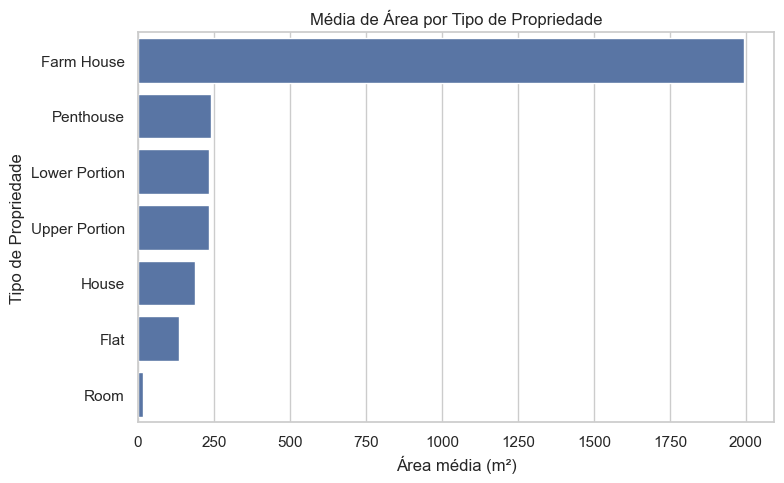

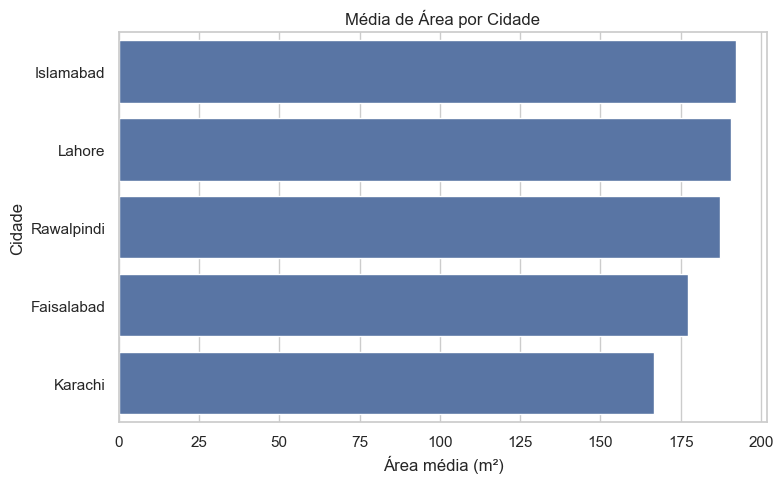

In [44]:
%matplotlib inline

media_area_por_tipo = (
    clean_df.groupby('property_type')['area']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
plt.figure(figsize=(8, 5))
sns.barplot(data=media_area_por_tipo, x='area', y='property_type')
plt.title('Média de Área por Tipo de Propriedade')
plt.xlabel('Área média (m²)')
plt.ylabel('Tipo de Propriedade')
plt.tight_layout()
plt.show()


media_area_por_cidade = (
    clean_df.groupby('city')['area']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
plt.figure(figsize=(8, 5))
sns.barplot(data=media_area_por_cidade, x='area', y='city')
plt.title('Média de Área por Cidade')
plt.xlabel('Área média (m²)')
plt.ylabel('Cidade')
plt.tight_layout()
plt.show()


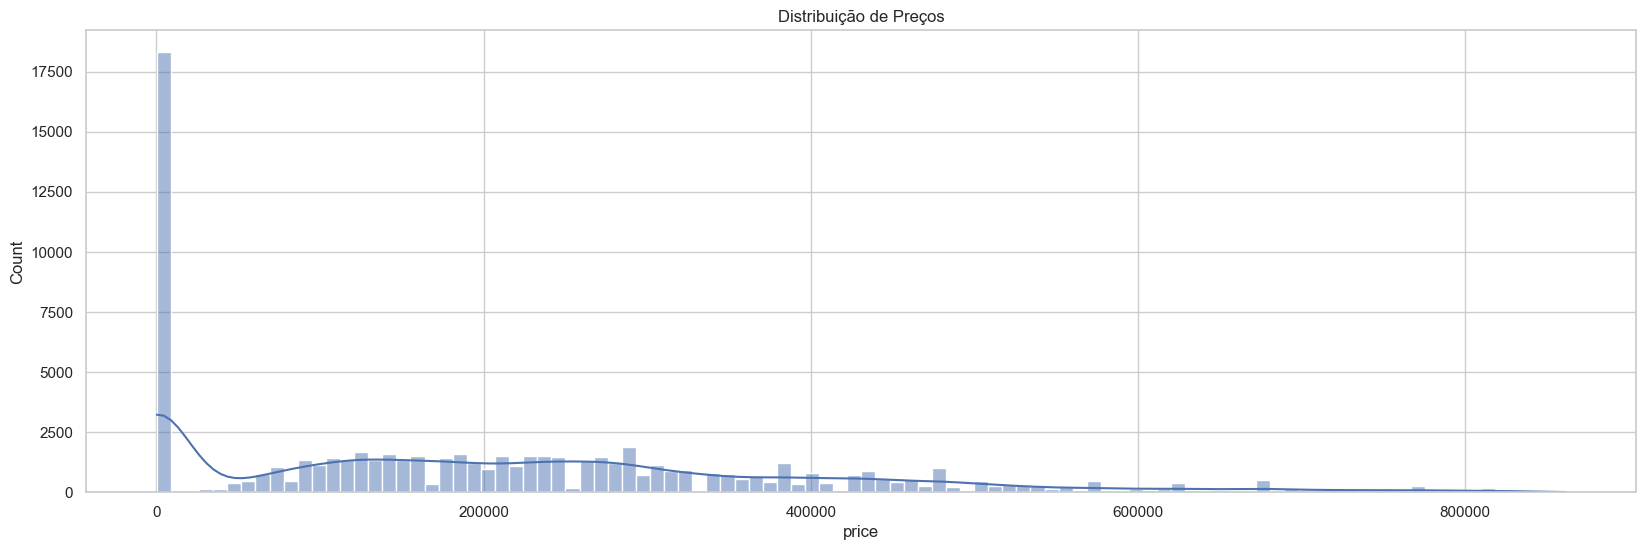

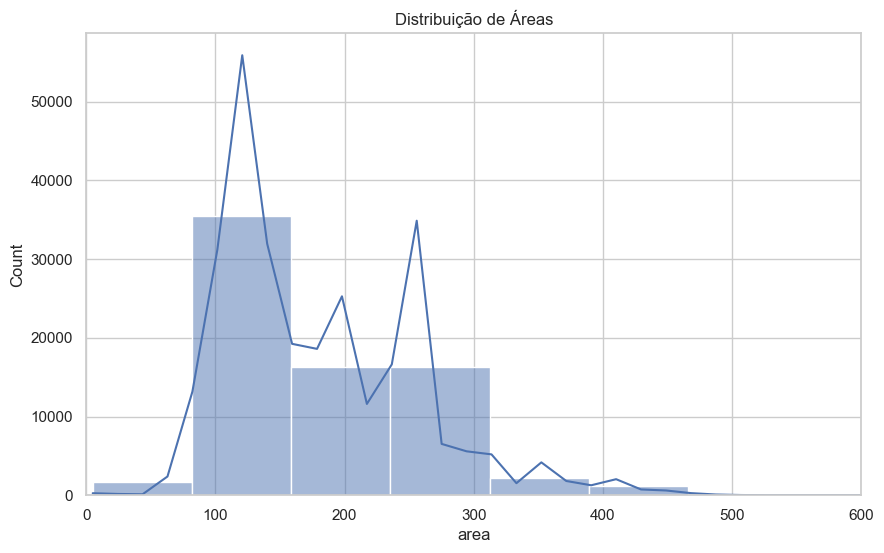

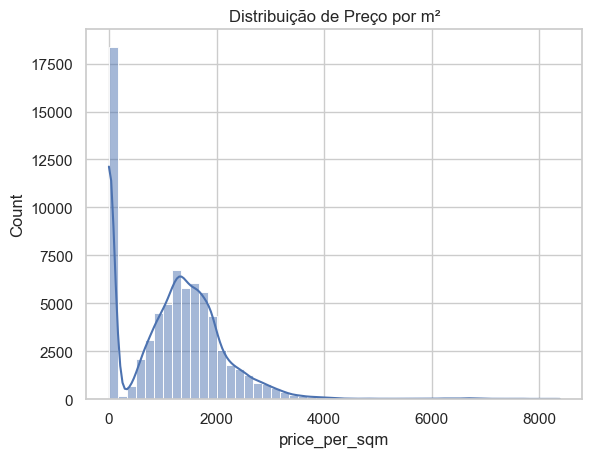

In [56]:
plt.figure(figsize=(20, 6))
sns.histplot(clean_df['price'], bins=100, kde=True)
plt.title('Distribuição de Preços')
# plt.xlim(0, 10000) # mostrar detalhamento da parte mais concentrada
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(clean_df['area'], bins=50, kde=True)
plt.title('Distribuição de Áreas')
plt.xlim(0, 600)
plt.show()

sns.histplot(clean_df['price_per_sqm'], bins=50, kde=True)
plt.title('Distribuição de Preço por m²')
plt.show()

#### 1. Preço Médio dos Imóveis:

Preço Médio dos Imóveis:  $207,361.82

  Preço médio por tipo de propriedade:


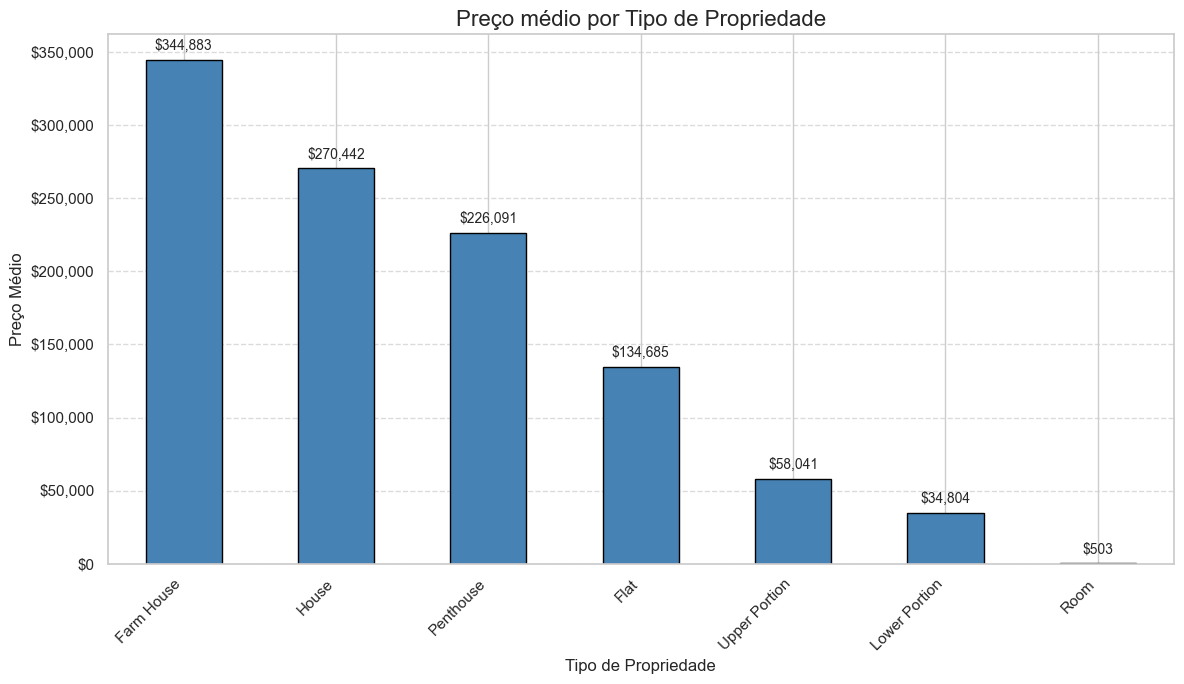

In [46]:
preco_medio = clean_df['price'].mean()
print(f"Preço Médio dos Imóveis:  ${preco_medio:,.2f}\n")

preco_medio_por_tipo = clean_df.groupby('property_type')['price'].mean().sort_values(ascending=False)
    
# Imprime a série formatada para melhor leitura
print("  Preço médio por tipo de propriedade:")
# print(preco_medio_por_tipo.to_string(float_format='{:,.2f}'.format))

plt.figure(figsize=(12, 7))
ax1 = preco_medio_por_tipo.plot(
    kind='bar',
    color='steelblue',
    edgecolor='black'
)

plt.title('Preço médio por Tipo de Propriedade', fontsize=16)
plt.xlabel('Tipo de Propriedade', fontsize=12)
plt.ylabel('Preço Médio', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Formatar o eixo Y como moeda
formatter = mticker.FuncFormatter(lambda x, p: f'${x:,.0f}')
ax1.yaxis.set_major_formatter(formatter)

# **Adicionar rótulos de dados (valores) nas barras**
for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(f'${height:,.0f}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom',
        xytext=(0, 5), textcoords='offset points',
        fontsize=10)

plt.tight_layout()
plt.show()

#### 1. Preço Médio dos Imóveis por m²:

   Preço médio por m² por tipo de propriedade:
property_type
House           $1,482.23
Flat              $960.67
Penthouse         $941.81
Upper Portion     $270.87
Farm House        $212.52
Lower Portion     $149.94
Room               $43.50


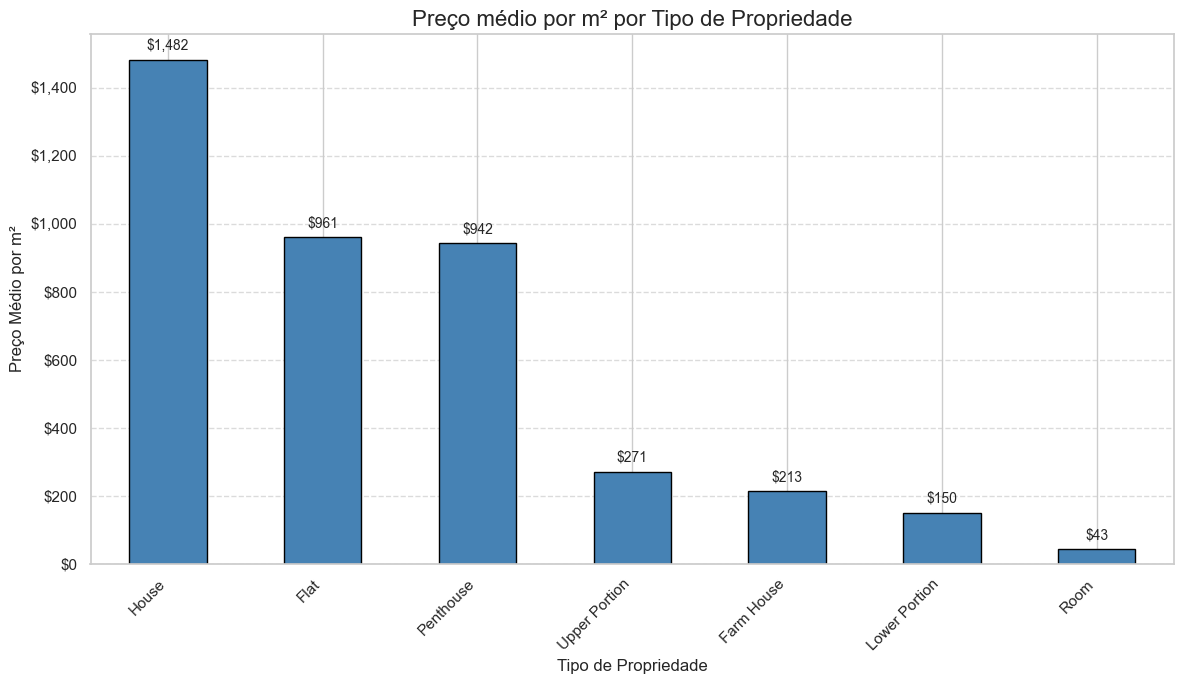

In [47]:

clean_df['price_per_m2'] = clean_df['price'] / clean_df['area']

# Remover valores nulos ou infinitos (caso 'area' fosse 0 ou 'price' nulo)
clean_df = clean_df.dropna(subset=['price_per_m2'])
clean_df = clean_df[~np.isinf(clean_df['price_per_m2'])]

# Cálculo modificado para usar 'price_per_m2'
preco_m2_por_tipo = clean_df.groupby('property_type')['price_per_m2'].mean().sort_values(ascending=False)
    
# Imprime a série formatada para melhor leitura
print("   Preço médio por m² por tipo de propriedade:")
print(preco_m2_por_tipo.to_string(float_format='${:,.2f}'.format))


plt.figure(figsize=(12, 7))
# Plot modificado para usar 'preco_m2_por_tipo'
ax1 = preco_m2_por_tipo.plot(
    kind='bar',
    color='steelblue',
    edgecolor='black'
)

# Títulos e rótulos atualizados
plt.title('Preço médio por m² por Tipo de Propriedade', fontsize=16)
plt.xlabel('Tipo de Propriedade', fontsize=12)
plt.ylabel('Preço Médio por m²', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Formatar o eixo Y como moeda (o formato ainda se aplica ao $/m²)
formatter = mticker.FuncFormatter(lambda x, p: f'${x:,.0f}')
ax1.yaxis.set_major_formatter(formatter)

# **Adicionar rótulos de dados (valores) nas barras**
for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(f'${height:,.0f}',
                 (p.get_x() + p.get_width() / 2., height),
                 ha='center', va='bottom',
                 xytext=(0, 5), textcoords='offset points',
                 fontsize=10)

plt.tight_layout()
plt.show()

#### 2. Distribuição dos Tipos de Propriedades:

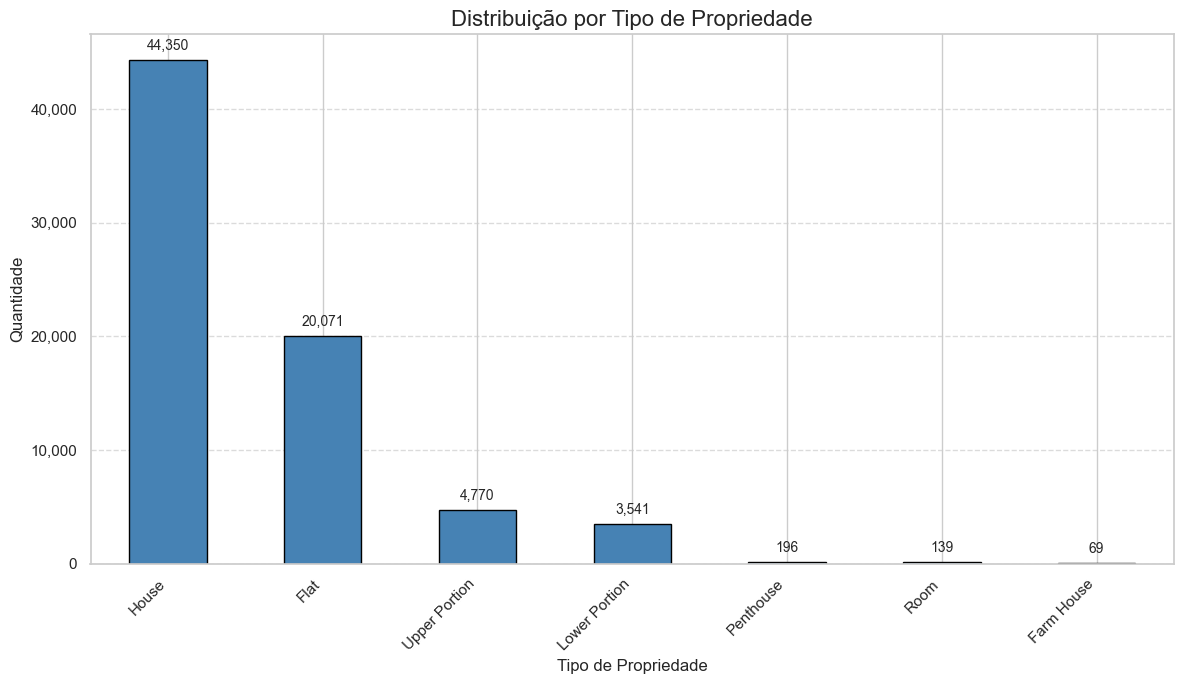

In [48]:

distribuicao_tipo = clean_df['property_type'].value_counts()
# print(distribuicao_tipo)
# print("\n")

plt.figure(figsize=(12, 7))
ax1 = distribuicao_tipo.plot(
    kind='bar',
    color='steelblue',
    edgecolor='black'
)

plt.title('Distribuição por Tipo de Propriedade', fontsize=16)
plt.xlabel('Tipo de Propriedade', fontsize=12)
plt.ylabel('Quantidade', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Formatar o eixo Y como moeda
formatter = mticker.FuncFormatter(lambda x, p: f'{x:,.0f}')
ax1.yaxis.set_major_formatter(formatter)

# **Adicionar rótulos de dados (valores) nas barras**
for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom',
        xytext=(0, 5), textcoords='offset points',
        fontsize=10)

plt.tight_layout()
plt.show()

#### 3. Média de preços por Cidade:

Média de preço de propriedades por cidade:
city
Lahore        310207.303939
Karachi       203375.713509
Faisalabad    164290.885824
Rawalpindi    149376.409021
Islamabad     134500.171751
Name: price, dtype: float64




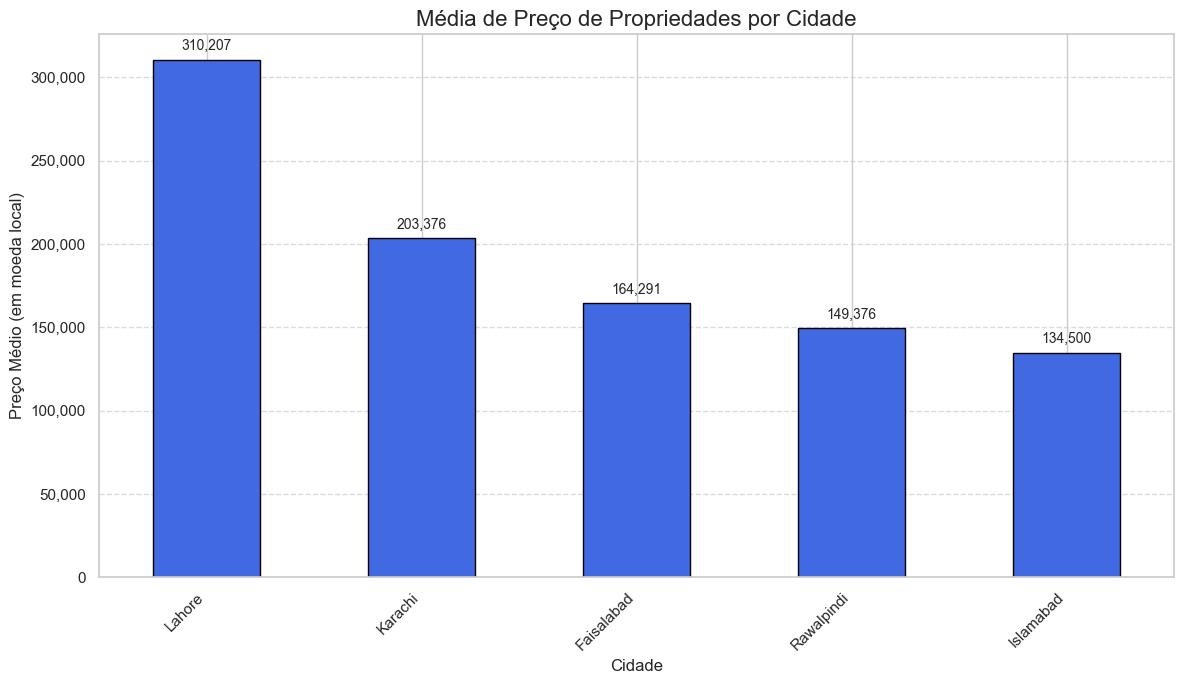

In [49]:
# Calcular média de preço por cidade
media_preco_por_cidade = (
    clean_df.groupby('city')['price']
    .mean()
    .sort_values(ascending=False)
)

# Mostrar no console
print("Média de preço de propriedades por cidade:")
print(media_preco_por_cidade)
print("\n")

# Plotar gráfico de barras
plt.figure(figsize=(12, 7))
ax1 = media_preco_por_cidade.plot(
    kind='bar',
    color='royalblue',
    edgecolor='black'
)

plt.title('Média de Preço de Propriedades por Cidade', fontsize=16)
plt.xlabel('Cidade', fontsize=12)
plt.ylabel('Preço Médio (em moeda local)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Formatar eixo Y como moeda
formatter = mticker.FuncFormatter(lambda x, p: f'{x:,.0f}')
ax1.yaxis.set_major_formatter(formatter)

# Adicionar rótulos de valores nas barras
for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom',
        xytext=(0, 5), textcoords='offset points',
        fontsize=10)

plt.tight_layout()
plt.show()

### Distribuição de tipo de propriedade por Cidade

property_type  Farm House   Flat  House  Lower Portion  Penthouse  Room  \
city                                                                      
Faisalabad              1      6   1459             76          0     8   
Islamabad              18   3692   7634           1876         23    98   
Karachi                15  14886  10340            907        163    29   
Lahore                 29    478  17694             10          3     1   
Rawalpindi              6   1009   7223            672          7     3   

property_type  Upper Portion  
city                          
Faisalabad               112  
Islamabad               2022  
Karachi                 1675  
Lahore                    14  
Rawalpindi               947  


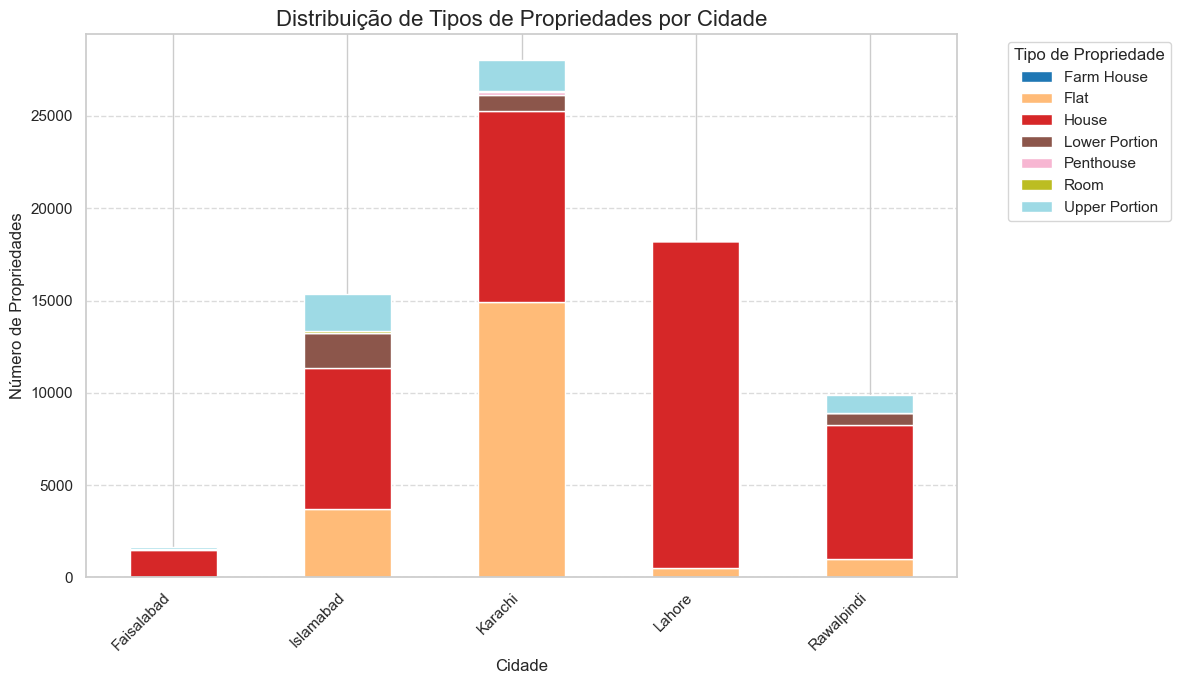

In [50]:
contagem_por_cidade_tipo = (
    clean_df.groupby(['city', 'property_type'])
    .size()
    .unstack(fill_value=0)
)

# Exibir a tabela resumida (opcional)
print(contagem_por_cidade_tipo)

# Plotar o gráfico empilhado
contagem_por_cidade_tipo.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7),
    colormap='tab20'  # boa paleta de cores variadas
)

plt.title('Distribuição de Tipos de Propriedades por Cidade', fontsize=16)
plt.xlabel('Cidade', fontsize=12)
plt.ylabel('Número de Propriedades', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tipo de Propriedade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Características das Propriedades (simples):

#### 4. Média de Quartos e Banheiros:

In [51]:
media_comodos = clean_df[['bedrooms', 'baths']].mean().round(2)
# mediana_comodos = clean_df[['bedrooms', 'baths']].median()

print(media_comodos)
print("\n")
# print(mediana_comodos)
# print("\n")

bedrooms    3.35
baths       3.54
dtype: float64




### Scatter plot de preço por área, dividido por tipo de propriedade

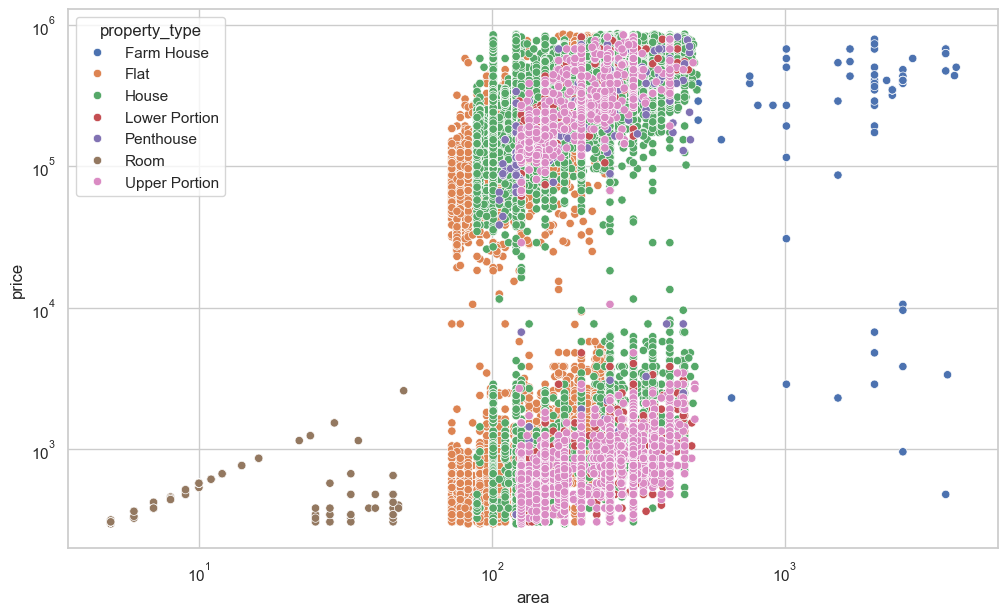

In [52]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=clean_df, x='area', y='price', hue='property_type')
plt.xscale('log'); plt.yscale('log')

### Top 10 - Bairros mais caros

Text(0.5, 1.0, 'Top 10 Localizações por Preço Médio/m²')

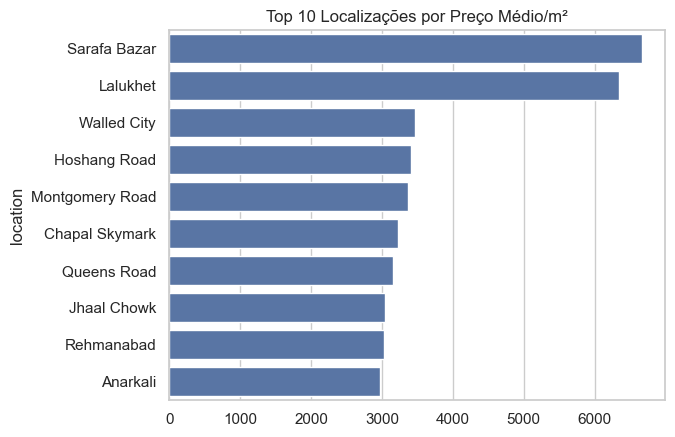

In [53]:
top_locs = clean_df.groupby('location')['price_per_sqm'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_locs.values, y=top_locs.index)
plt.title('Top 10 Localizações por Preço Médio/m²')

### **Salvando dataset como CSV para fazer as predições em outros arquivos**

In [54]:
clean_df.to_csv('dataset_tratado.csv', index=False)